# Lecture 1 · Simple Linear Regression — Salary Data

Following `1__Simple_Linear_Regression.pdf` (Kutner, Nachtsheim, Neter & Li, 2005, Ch. 1–2).

**Data:** `Salary_Data.csv`, $n=30$, $X$ = YearsExperience, $Y$ = Salary.

### Why this notebook differs from the usual sklearn treatment

A typical machine-learning notebook fits this data with `sklearn.LinearRegression` on a train/test
split and reports $R^2$, MAE and RMSE — quantities about **predictive error**.

The lecture (Kutner) is about **inference**: the standard error of $b_1$, its confidence interval,
the $t$ test, the ANOVA $F$ test. `sklearn` does not provide any of these.

This notebook therefore uses the **full sample** (no split) and computes each quantity from the
formula in the slides, with every result labelled by the slide it comes from.

In [1]:
import numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

d = pd.read_csv('Salary_Data.csv')
X = d['YearsExperience'].to_numpy()
Y = d['Salary'].to_numpy()
n = len(X)
d.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


## Slide 9 · Descriptive quantities

The lecture first lists $\bar X$, $\bar Y$ and $\sum(X_i-\bar X)^2$ for the Toluca example —
every later formula is built from them.

In [2]:
Xbar, Ybar = X.mean(), Y.mean()
Sxx = ((X - Xbar)**2).sum()              # sum (Xi - Xbar)^2
Sxy = ((X - Xbar)*(Y - Ybar)).sum()
Syy = ((Y - Ybar)**2).sum()              # this becomes SSTO later
print(f'n    = {n}')
print(f'Xbar = {Xbar:.4f}   Ybar = {Ybar:,.2f}')
print(f'Sxx  = {Sxx:.4f}')

n    = 30
Xbar = 5.3133   Ybar = 76,003.00
Sxx  = 233.5547


## Slides 10–11 · Least squares estimators (1.10a–b)

$$b_1=\frac{\sum(X_i-\bar X)(Y_i-\bar Y)}{\sum(X_i-\bar X)^2},\qquad b_0=\bar Y-b_1\bar X$$

In [3]:
b1 = Sxy / Sxx
b0 = Ybar - b1 * Xbar
print(f'b1 = {b1:,.4f}    each additional year of experience adds about {b1:,.0f} to mean salary')
print(f'b0 = {b0:,.4f}    mean response at X = 0 (is X = 0 within the scope of the model?)')
print(f'\nFitted regression function:  Yhat = {b0:,.2f} + {b1:,.2f} * X')

b1 = 9,449.9623    each additional year of experience adds about 9,450 to mean salary
b0 = 25,792.2002    mean response at X = 0 (is X = 0 within the scope of the model?)

Fitted regression function:  Yhat = 25,792.20 + 9,449.96 * X


## Slides 13–14 · Fitted values, residuals, and algebraic properties

The lecture lists properties of the least-squares fit. Two of them serve as a **correctness check**:
$\sum e_i = 0$ and $\sum X_i e_i = 0$.

These are mathematical consequences of least squares, not properties of the data — if they do not
hold, the code is wrong.

In [4]:
Yhat = b0 + b1 * X
e = Y - Yhat                # residual e_i; distinct from the unknown error eps_i
print(f'sum(e_i)     = {e.sum():.6e}   (should be 0)')
print(f'sum(X_i e_i) = {(X*e).sum():.6e}   (should be 0)')
print(f'\nYhat at X = 5: {b0 + b1*5:,.2f}')

sum(e_i)     = 0.000000e+00   (should be 0)
sum(X_i e_i) = -1.527951e-10   (should be 0)

Yhat at X = 5: 73,042.01


## Slide 15 · Estimating the error variance $\sigma^2$

$$SSE=\sum e_i^2,\qquad MSE=s^2=\frac{SSE}{n-2}$$

The divisor is $n-2$, not $n$: one degree of freedom is spent estimating each of
$\beta_0$ and $\beta_1$.

In [5]:
SSE = (e**2).sum()
MSE = SSE / (n - 2)
s   = np.sqrt(MSE)
print(f'SSE = {SSE:,.1f}')
print(f'MSE = {MSE:,.1f}   (df = {n-2})')
print(f's   = {s:,.2f}      typical deviation from the fitted line')

SSE = 938,128,551.7
MSE = 33,504,591.1   (df = 28)
s   = 5,788.32      typical deviation from the fitted line


# Chapter 2 · Inference

**Everything below is what `sklearn` does not give you.**

## Slide 19 · Sampling distribution of $b_1$

$$\sigma^2\{b_1\}=\frac{\sigma^2}{\sum(X_i-\bar X)^2}
\quad\Longrightarrow\quad
s^2\{b_1\}=\frac{MSE}{\sum(X_i-\bar X)^2}$$

In [6]:
s2_b1 = MSE / Sxx
s_b1  = np.sqrt(s2_b1)
print(f's2{{b1}} = {s2_b1:,.2f}')
print(f's{{b1}}  = {s_b1:.4f}')

s2{b1} = 143,455.03
s{b1}  = 378.7546


## Slide 21 · Confidence interval for $\beta_1$ (2.15)

$$b_1\pm t\!\left(1-\tfrac{\alpha}{2};\,n-2\right)s\{b_1\}$$

In [7]:
alpha = 0.05
tcrit = stats.t.ppf(1 - alpha/2, n - 2)
lo, hi = b1 - tcrit*s_b1, b1 + tcrit*s_b1
print(f't({1-alpha/2:.3f}; {n-2}) = {tcrit:.4f}')
print(f'95% CI for beta1: [{lo:,.2f}, {hi:,.2f}]')
print(f'\nWith 95% confidence, mean salary increases by between {lo:,.0f} and {hi:,.0f}')
print('per additional year of experience.')

t(0.975; 28) = 2.0484
95% CI for beta1: [8,674.12, 10,225.81]

With 95% confidence, mean salary increases by between 8,674 and 10,226
per additional year of experience.


## Slide 22 · Testing whether $\beta_1 = 0$

$$H_0:\beta_1=0\quad\text{vs.}\quad H_a:\beta_1\neq 0,\qquad t^*=\frac{b_1}{s\{b_1\}}$$

In [8]:
tstar = b1 / s_b1
pval  = 2 * stats.t.sf(abs(tstar), n - 2)
print(f't*            = {tstar:.4f}')
print(f'critical value = {tcrit:.4f}')
print(f'P-value        = {pval:.3e}')
print(f'\n|t*| > critical value  ->  reject H0: a linear association is present.')
print('Equivalently, the 95% CI for beta1 excludes 0.')

t*            = 24.9501
critical value = 2.0484
P-value        = 1.143e-20

|t*| > critical value  ->  reject H0: a linear association is present.
Equivalently, the 95% CI for beta1 excludes 0.


## Slide 23 · Inference concerning $\beta_0$

$$s^2\{b_0\}=MSE\left[\frac{1}{n}+\frac{\bar X^2}{\sum(X_i-\bar X)^2}\right]$$

⚠️ Caution from the lecture: **$\beta_0$ has a direct meaning only if $X=0$ lies within the
scope of the model.**

In [9]:
s2_b0 = MSE * (1/n + Xbar**2 / Sxx)
s_b0  = np.sqrt(s2_b0)
print(f's{{b0}} = {s_b0:,.2f}')
print(f'95% CI for beta0: [{b0 - tcrit*s_b0:,.1f}, {b0 + tcrit*s_b0:,.1f}]')
print(f'\nObserved range of X: [{X.min()}, {X.max()}] — X = 0 is outside it,')
print('so b0 is a mathematical intercept, not a "starting salary".')

s{b0} = 2,273.05
95% CI for beta0: [21,136.1, 30,448.3]

Observed range of X: [1.1, 10.5] — X = 0 is outside it,
so b0 is a mathematical intercept, not a "starting salary".


## Slides 24–25 · Two intervals: mean response vs. a new observation

$$s^2\{\hat Y_h\}=MSE\left[\frac1n+\frac{(X_h-\bar X)^2}{\sum(X_i-\bar X)^2}\right]
\qquad
s^2\{pred\}=MSE\left[\,\mathbf{1}+\frac1n+\frac{(X_h-\bar X)^2}{\sum(X_i-\bar X)^2}\right]$$

**The difference is the extra $1$.** Predicting a new individual carries the uncertainty of
estimating the mean **plus** that individual's own scatter $\sigma^2$.

In [10]:
Xh = 5.0
Yh = b0 + b1*Xh
s_Yh   = np.sqrt(MSE * (1/n + (Xh-Xbar)**2/Sxx))
s_pred = np.sqrt(MSE * (1 + 1/n + (Xh-Xbar)**2/Sxx))
print(f'Xh = {Xh} years of experience  ->  Yhat = {Yh:,.2f}\n')
print(f'Mean response E{{Yh}}   s = {s_Yh:8,.2f}   95% CI = [{Yh-tcrit*s_Yh:,.0f}, {Yh+tcrit*s_Yh:,.0f}]')
print(f'New observation Yh(new) s = {s_pred:8,.2f}   95% PI = [{Yh-tcrit*s_pred:,.0f}, {Yh+tcrit*s_pred:,.0f}]')
print(f'\nThe prediction interval is {(s_pred/s_Yh):.1f} times wider than the confidence interval.')

Xh = 5.0 years of experience  ->  Yhat = 73,042.01

Mean response E{Yh}   s = 1,063.44   95% CI = [70,864, 75,220]
New observation Yh(new) s = 5,885.19   95% PI = [60,987, 85,097]

The prediction interval is 5.5 times wider than the confidence interval.


## Slide 26 · The two bands — narrowest at $\bar X$, flaring outward

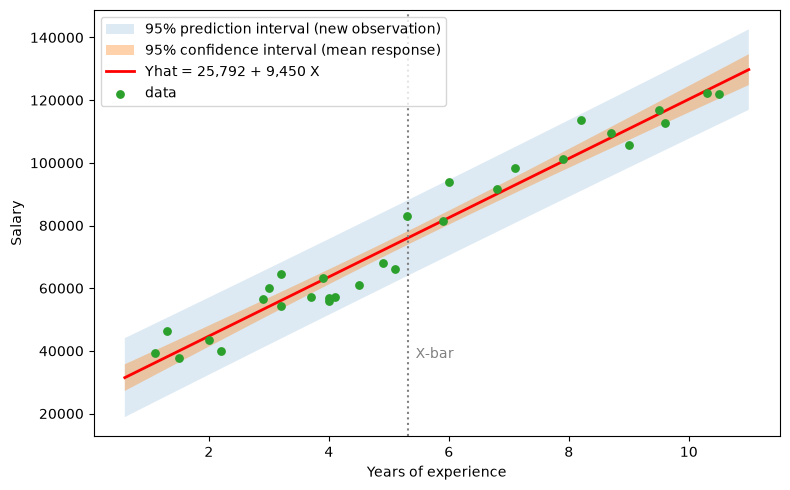

In [11]:
grid = np.linspace(X.min()-0.5, X.max()+0.5, 200)
fit  = b0 + b1*grid
se_m = np.sqrt(MSE * (1/n + (grid-Xbar)**2/Sxx))
se_p = np.sqrt(MSE * (1 + 1/n + (grid-Xbar)**2/Sxx))

plt.figure(figsize=(8,5))
plt.fill_between(grid, fit-tcrit*se_p, fit+tcrit*se_p, alpha=.15,
                 label='95% prediction interval (new observation)')
plt.fill_between(grid, fit-tcrit*se_m, fit+tcrit*se_m, alpha=.35,
                 label='95% confidence interval (mean response)')
plt.plot(grid, fit, 'r-', lw=2, label=f'Yhat = {b0:,.0f} + {b1:,.0f} X')
plt.scatter(X, Y, s=28, zorder=5, label='data')
plt.axvline(Xbar, ls=':', c='gray'); plt.text(Xbar, Y.min(), '  X-bar', c='gray')
plt.xlabel('Years of experience'); plt.ylabel('Salary')
plt.legend(); plt.tight_layout(); plt.show()

## Slides 27–30 · ANOVA and the $F$ test

$$SSTO=SSR+SSE,\qquad F^*=\frac{MSR}{MSE}$$

In simple linear regression the $F$ test and the $t$ test are **identical**: $F^*=(t^*)^2$.

In [12]:
SSR   = ((Yhat - Ybar)**2).sum()
SSTO  = Syy
MSR   = SSR / 1
Fstar = MSR / MSE
Fcrit = stats.f.ppf(0.95, 1, n-2)

print(f'{"Source":<12}{"SS":>20}{"df":>5}{"MS":>20}{"F*":>10}')
print(f'{"Regression":<12}{SSR:>20,.0f}{1:>5}{MSR:>20,.0f}{Fstar:>10.2f}')
print(f'{"Error":<12}{SSE:>20,.0f}{n-2:>5}{MSE:>20,.0f}')
print(f'{"Total":<12}{SSTO:>20,.0f}{n-1:>5}')
print(f'\nF(0.95; 1, {n-2}) = {Fcrit:.2f}  ->  F* exceeds it, reject H0')
print(f'Equivalence check: (t*)^2 = {tstar**2:.2f}  ==  F* = {Fstar:.2f}')

Source                        SS   df                  MS        F*
Regression        20,856,849,300    1      20,856,849,300    622.51
Error                938,128,552   28          33,504,591
Total             21,794,977,852   29

F(0.95; 1, 28) = 4.20  ->  F* exceeds it, reject H0
Equivalence check: (t*)^2 = 622.51  ==  F* = 622.51


## Slides 31–32 · $R^2$, $r$, and the cautions

$$R^2=\frac{SSR}{SSTO}=1-\frac{SSE}{SSTO},\qquad r=\pm\sqrt{R^2}\ \ (\text{sign of } b_1)$$

In [13]:
R2 = SSR / SSTO
r  = np.sign(b1) * np.sqrt(R2)
print(f'R2 = {R2:.4f}   about {R2*100:.1f}% of the variation in salary is accounted for by experience')
print(f'r  = {r:.4f}    (matches np.corrcoef: {np.corrcoef(X,Y)[0,1]:.6f})')
print('''
Slide 32 cautions, applied to this dataset:
  - A high R2 does NOT guarantee useful predictions
        -> the prediction interval here spans about +/- 12,000
  - A high R2 does NOT imply the model form is correct
        -> residual plots are still required to check for curvature
  - R2 depends on the spread of the Xi
        -> experience ranges 1.1-10.5 years here, a wide range, which inflates R2
  - Correlation is not causation
        -> this does not say that staying one more year causes the increase
''')

R2 = 0.9570   about 95.7% of the variation in salary is accounted for by experience
r  = 0.9782    (matches np.corrcoef: 0.978242)

Slide 32 cautions, applied to this dataset:
  - A high R2 does NOT guarantee useful predictions
        -> the prediction interval here spans about +/- 12,000
  - A high R2 does NOT imply the model form is correct
        -> residual plots are still required to check for curvature
  - R2 depends on the spread of the Xi
        -> experience ranges 1.1-10.5 years here, a wide range, which inflates R2
  - Correlation is not causation
        -> this does not say that staying one more year causes the increase



## Cross-check against `statsmodels`

Every hand-computed quantity above should appear in the OLS summary. This is the standard way
to verify that the formulas were implemented correctly.

In [14]:
import statsmodels.api as sm
fit_sm = sm.OLS(Y, sm.add_constant(X)).fit()
print(fit_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     622.5
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           1.14e-20
Time:                        09:42:01   Log-Likelihood:                -301.44
No. Observations:                  30   AIC:                             606.9
Df Residuals:                      28   BIC:                             609.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.579e+04   2273.053     11.347      0.0

## Residual diagnostics (Lecture 3 material — a first look)

In the final-project rubric, *diagnostics and validation of model assumptions* is the single
heaviest criterion at **25 points**.

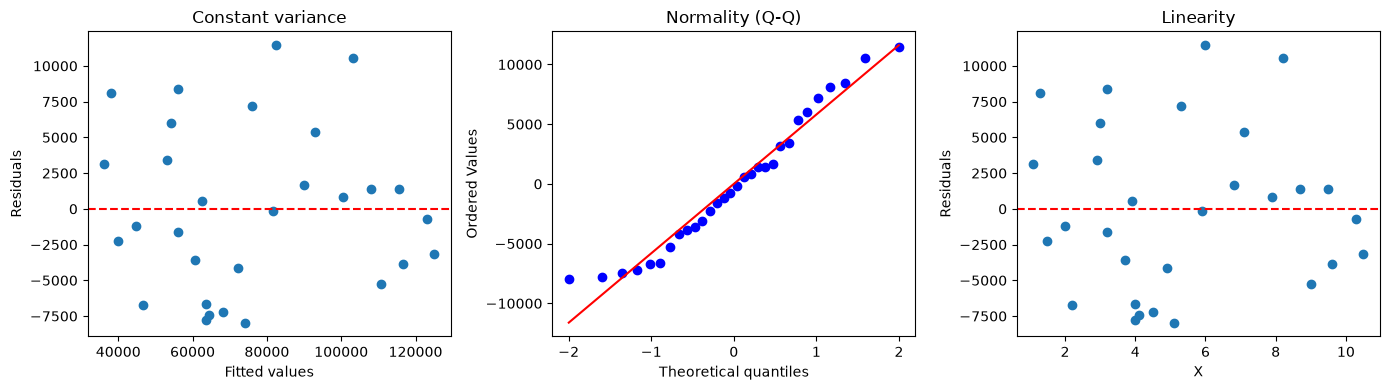

Shapiro-Wilk normality test: W = 0.9523, p = 0.1952
Durbin-Watson (independence): 1.6480


In [15]:
fig, ax = plt.subplots(1, 3, figsize=(14,4))
ax[0].scatter(Yhat, e); ax[0].axhline(0, c='r', ls='--')
ax[0].set_xlabel('Fitted values'); ax[0].set_ylabel('Residuals')
ax[0].set_title('Constant variance')
stats.probplot(e, dist='norm', plot=ax[1]); ax[1].set_title('Normality (Q-Q)')
ax[2].scatter(X, e); ax[2].axhline(0, c='r', ls='--')
ax[2].set_xlabel('X'); ax[2].set_ylabel('Residuals'); ax[2].set_title('Linearity')
plt.tight_layout(); plt.show()

W, p_sw = stats.shapiro(e)
print(f'Shapiro-Wilk normality test: W = {W:.4f}, p = {p_sw:.4f}')
print(f'Durbin-Watson (independence): {sm.stats.durbin_watson(e):.4f}')